# SAM-Med2D — Kiểm tra phòng hộ khi prompt sai

**Câu hỏi:**
1. Khi prompt đặt vào góc tối (≥70% đen), SAM-Med2D có bị phát hiện *suspicious* theo cùng 5 tiêu chí của PGA không?
2. GradCAM trên SAM có tạo gợi ý hữu ích (trỏ đúng vùng tổn thương) như PGA không?

Nhận xét: PGA đã có test riêng — notebook này chỉ test SAM.

Chạy tuần tự: **Setup → writefile → Load SAM → Test phòng hộ → GradCAM → Kết quả**

In [8]:
%cd /kaggle/working
!git clone https://github.com/OpenGVLab/SAM-Med2D/
%cd /kaggle/working/SAM-Med2D
!pip install -e . -q

/kaggle/working
fatal: destination path 'SAM-Med2D' already exists and is not an empty directory.
/kaggle/working/SAM-Med2D
ERROR: file:///kaggle/working/SAM-Med2D does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [9]:
# Tải SAM base checkpoint
!mkdir -p /kaggle/working/SAM-Med2D/checkpoint
!gdown "https://drive.google.com/uc?id=1ARiB5RkSsWmAB_8mqWnwDF8ZKTtFwsjl" \
    -O /kaggle/working/SAM-Med2D/checkpoint/sam_med2d.pth
!ls -lh /kaggle/working/SAM-Med2D/checkpoint

Downloading...
From (original): https://drive.google.com/uc?id=1ARiB5RkSsWmAB_8mqWnwDF8ZKTtFwsjl
From (redirected): https://drive.google.com/uc?id=1ARiB5RkSsWmAB_8mqWnwDF8ZKTtFwsjl&confirm=t&uuid=3bcfbc50-2964-4566-b7c1-a10db3acad1b
To: /kaggle/working/SAM-Med2D/checkpoint/sam_med2d.pth
100%|██████████████████████████████████████| 2.56G/2.56G [00:39<00:00, 64.4MB/s]
total 2.4G
-rw-r--r-- 1 root root 2.4G Aug 18  2023 sam_med2d.pth


In [10]:
# Download dataset
%cd /kaggle/working/SAM-Med2D
import os, gdown
gdown.download('https://drive.google.com/uc?id=1fU7KPln7joaa3EZZtGn-VKeg9i4AmPG3',
               '/kaggle/working/dataset_BTXRD.zip', quiet=False)
!unzip -oq /kaggle/working/dataset_BTXRD.zip -d /kaggle/working/SAM-Med2D/
print('✅ Dataset ready')
print('Test images :', len(os.listdir('dataset_BTXRD/test/images')))
print('Test annotations:', len(os.listdir('dataset_BTXRD/test/annotations')))

/kaggle/working/SAM-Med2D


Downloading...
From (original): https://drive.google.com/uc?id=1fU7KPln7joaa3EZZtGn-VKeg9i4AmPG3
From (redirected): https://drive.google.com/uc?id=1fU7KPln7joaa3EZZtGn-VKeg9i4AmPG3&confirm=t&uuid=f7ad295a-2467-468e-b595-98ecf21b4ee3
To: /kaggle/working/dataset_BTXRD.zip
100%|██████████| 1.50G/1.50G [00:07<00:00, 205MB/s]


✅ Dataset ready
Test images : 187
Test annotations: 187


In [11]:
%%writefile /kaggle/working/SAM-Med2D/segment_anything/build_sam.py
# Copyright (c) Meta Platforms, Inc. and affiliates.
# All rights reserved.
# This source code is licensed under the license found in the
# LICENSE file in the root directory of this source tree.

import torch
from functools import partial
from .modeling import ImageEncoderViT, MaskDecoder, PromptEncoder, Sam, TwoWayTransformer
from torch.nn import functional as F

def build_sam_vit_h(args):
    return _build_sam(
        encoder_embed_dim=1280, encoder_depth=32,
        encoder_num_heads=16, encoder_global_attn_indexes=[7,15,23,31],
        image_size=args.image_size, checkpoint=args.sam_checkpoint,
        encoder_adapter=args.encoder_adapter,
    )

build_sam = build_sam_vit_h

def build_sam_vit_l(args):
    return _build_sam(
        encoder_embed_dim=1024, encoder_depth=24,
        encoder_num_heads=16, encoder_global_attn_indexes=[5,11,17,23],
        image_size=args.image_size, checkpoint=args.sam_checkpoint,
        encoder_adapter=args.encoder_adapter,
    )

def build_sam_vit_b(args):
    return _build_sam(
        encoder_embed_dim=768, encoder_depth=12,
        encoder_num_heads=12, encoder_global_attn_indexes=[2,5,8,11],
        image_size=args.image_size, checkpoint=args.sam_checkpoint,
        encoder_adapter=args.encoder_adapter,
    )

sam_model_registry = {
    'default': build_sam_vit_h, 'vit_h': build_sam_vit_h,
    'vit_l': build_sam_vit_l,  'vit_b': build_sam_vit_b,
}

def _build_sam(encoder_embed_dim, encoder_depth, encoder_num_heads,
               encoder_global_attn_indexes, image_size, checkpoint, encoder_adapter):
    prompt_embed_dim   = 256
    vit_patch_size     = 16
    image_embedding_size = image_size // vit_patch_size
    sam = Sam(
        image_encoder=ImageEncoderViT(
            depth=encoder_depth, embed_dim=encoder_embed_dim,
            img_size=image_size, mlp_ratio=4,
            norm_layer=partial(torch.nn.LayerNorm, eps=1e-6),
            num_heads=encoder_num_heads, patch_size=vit_patch_size,
            qkv_bias=True, use_rel_pos=True,
            global_attn_indexes=encoder_global_attn_indexes,
            window_size=14, out_chans=prompt_embed_dim,
            adapter_train=encoder_adapter,
        ),
        prompt_encoder=PromptEncoder(
            embed_dim=prompt_embed_dim,
            image_embedding_size=(image_embedding_size, image_embedding_size),
            input_image_size=(image_size, image_size),
            mask_in_chans=16,
        ),
        mask_decoder=MaskDecoder(
            num_multimask_outputs=3,
            transformer=TwoWayTransformer(
                depth=2, embedding_dim=prompt_embed_dim,
                mlp_dim=2048, num_heads=8,
            ),
            transformer_dim=prompt_embed_dim,
            iou_head_depth=3, iou_head_hidden_dim=256,
        ),
        pixel_mean=[123.675, 116.28, 103.53],
        pixel_std=[58.395, 57.12, 57.375],
    )
    if checkpoint is not None:
        with open(checkpoint, 'rb') as f:
            state_dict = torch.load(f, map_location='cpu', weights_only=False)
        try:
            if 'model' in state_dict:
                sam.load_state_dict(state_dict['model'], strict=False)
            else:
                sam.load_state_dict(state_dict)
        except Exception:
            new_sd = load_from(sam, state_dict, image_size, vit_patch_size)
            sam.load_state_dict(new_sd)
        print(f'*******load {checkpoint}')
    return sam

def load_from(sam, state_dicts, image_size, vit_patch_size):
    sam_dict  = sam.state_dict()
    skip_keys = ['mask_tokens','output_hypernetworks_mlps','iou_prediction_head']
    new_sd = {k: v for k, v in state_dicts.items()
              if k in sam_dict and not any(s in k for s in skip_keys)}
    pos_embed  = new_sd.get('image_encoder.pos_embed')
    token_size = image_size // vit_patch_size
    if pos_embed is not None and pos_embed.shape[1] != token_size:
        pos_embed = pos_embed.permute(0,3,1,2)
        pos_embed = F.interpolate(pos_embed,(token_size,token_size),mode='bilinear',align_corners=False)
        new_sd['image_encoder.pos_embed'] = pos_embed.permute(0,2,3,1)
        for k in [k for k in sam_dict if 'rel_pos' in k]:
            rp = new_sd.get(k)
            if rp is None: continue
            h_c, w_c = sam_dict[k].shape
            if rp.shape != (h_c, w_c):
                rp2 = F.interpolate(rp.unsqueeze(0).unsqueeze(0),(h_c,w_c),
                                    mode='bilinear',align_corners=False)
                new_sd[k] = rp2[0,0]
    sam_dict.update(new_sd)
    return sam_dict

Overwriting /kaggle/working/SAM-Med2D/segment_anything/build_sam.py


In [12]:
# ── Load SAM fine-tuned + utilities ──────────────────────────────────
import sys, os, cv2, json as _json, argparse
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt

%cd /kaggle/working/SAM-Med2D
sys.path.insert(0, '/kaggle/working/SAM-Med2D')
from segment_anything import sam_model_registry

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE_SAM = 256
IMG_DIR      = 'dataset_BTXRD/test/images'
JSON_DIR     = 'dataset_BTXRD/test/annotations'

# Tìm checkpoint fine-tuned (ưu tiên Drive)
CHECKPOINT = ''
for p in ['/kaggle/working/drive/MyDrive/model/best_sam.pth',
          '/kaggle/working/drive/MyDrive/results/best_sam.pth',
          'workdir/models/sam-med2d/best_sam.pth']:
    if os.path.exists(p): CHECKPOINT = p; break
if not CHECKPOINT:
    # Download từ Drive ID
    import gdown
    CHECKPOINT = '/kaggle/working/SAM-Med2D/best_sam.pth'
    gdown.download('https://drive.google.com/uc?id=1fTEhbgpEzzEqdB8CEW8wH8KnX1YlJJM4',
                   CHECKPOINT, quiet=False)
assert os.path.exists(CHECKPOINT), '❌ Không tìm thấy checkpoint'
print(f'✅ Checkpoint: {CHECKPOINT}  ({os.path.getsize(CHECKPOINT)//1024:,} KB)')

# Load model — args truyền vào build_sam_vit_b đúng cách
args_sam = argparse.Namespace(
    image_size      = IMG_SIZE_SAM,
    encoder_adapter = True,
    sam_checkpoint  = CHECKPOINT,   # build_sam tự load fine-tuned weights
)
model = sam_model_registry['vit_b'](args_sam).to(DEVICE)
model.eval()
print(f'✅ SAM-Med2D loaded [{DEVICE}]')

# ── Utilities ─────────────────────────────────────────────────────────
def extract_lcc(m):
    if m.sum()==0: return m
    n,lbl,st,_ = cv2.connectedComponentsWithStats(m.astype(np.uint8),8)
    return m if n<=1 else (lbl==(1+np.argmax(st[1:,cv2.CC_STAT_AREA]))).astype(np.float32)

def calc_dice(prob, gt, eps=1e-6):
    pm = extract_lcc((prob>0.5).astype(np.float32))
    gm = (gt>0.5).astype(np.float32)
    tp=(pm*gm).sum(); fp=(pm*(1-gm)).sum(); fn=((1-pm)*gm).sum()
    return float((2*tp+eps)/(2*tp+fp+fn+eps))

def plateau_heatmap(bbox, S):
    x1=max(0,int(bbox[0])-5); y1=max(0,int(bbox[1])-5)
    x2=min(S,int(bbox[2])+5); y2=min(S,int(bbox[3])+5)
    hm=np.zeros((S,S),dtype=np.float32)
    if x2>x1 and y2>y1:
        hm[y1:y2,x1:x2]=1.0
        hm=cv2.GaussianBlur(hm,(31,31),0)
    return hm

def sam_infer(img_gray_uint8, box_xyxy):
    """img_gray_uint8: HxW uint8, box_xyxy: [x1,y1,x2,y2] ở 256×256."""
    img_rgb = cv2.cvtColor(img_gray_uint8, cv2.COLOR_GRAY2RGB)
    img_t   = model.preprocess(torch.from_numpy(img_rgb).permute(2,0,1).unsqueeze(0).float().to(DEVICE))
    box_t   = torch.tensor([[list(box_xyxy)]],dtype=torch.float32,device=DEVICE)
    with torch.no_grad():
        emb        = model.image_encoder(img_t)
        se, de     = model.prompt_encoder(points=None, boxes=box_t, masks=None)
        low_res, _ = model.mask_decoder(
            image_embeddings=emb, image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=se, dense_prompt_embeddings=de,
            multimask_output=False,
        )
    prob = torch.sigmoid(F.interpolate(low_res,(256,256),mode='bilinear',align_corners=False))
    return prob[0,0].cpu().numpy()

# ── Hàm phòng hộ — 5 tiêu chí giống PGA ──────────────────────────────
CONF_THR   = 0.80
DIST_RATIO = 0.25
DARK_THR   = 30          # pixel uint8 < 30 → coi là đen (không phụ thuộc normalization)
DARK_RATIO = 0.70

def is_suspicious(prob_np, pm_np, img_uint8, S):
    """Áp 5 tiêu chí, img_uint8 là ảnh grayscale 0-255."""
    pred        = (prob_np>0.5).astype(np.float32)
    conf        = float(prob_np.max())
    ys_p, xs_p  = np.where(pm_np>0.3)
    cx_pmt      = xs_p.mean() if len(xs_p) else S/2
    cy_pmt      = ys_p.mean() if len(ys_p) else S/2
    prompt_area = len(xs_p)
    ys_r, xs_r  = np.where(pred>0.5)
    pred_area   = int(pred.sum())
    dist        = float(np.sqrt((xs_r.mean()-cx_pmt)**2+(ys_r.mean()-cy_pmt)**2)) \
                  if len(xs_r)>0 else float(S)
    s_conf  = conf < CONF_THR
    s_dist  = dist > S*DIST_RATIO
    s_area  = pred_area < 50
    s_ratio = (prompt_area>0) and (pred_area/float(prompt_area)<0.05)
    pm_mask = pm_np>0.3
    dark_ratio = float((img_uint8[pm_mask] < DARK_THR).sum()/pm_mask.sum()) \
                 if pm_mask.sum()>0 else 1.0
    s_dark  = dark_ratio > DARK_RATIO
    reasons = dict(CONF=s_conf,DIST=s_dist,AREA=s_area,RATIO=s_ratio,DARK=s_dark)
    return any(reasons.values()), reasons

print('✅ Utilities sẵn sàng')

/kaggle/working/SAM-Med2D


Downloading...
From (original): https://drive.google.com/uc?id=1fTEhbgpEzzEqdB8CEW8wH8KnX1YlJJM4
From (redirected): https://drive.google.com/uc?id=1fTEhbgpEzzEqdB8CEW8wH8KnX1YlJJM4&confirm=t&uuid=b4fd1213-2835-45fb-ad7b-22a4b04dd416
To: /kaggle/working/SAM-Med2D/best_sam.pth
100%|██████████| 2.56G/2.56G [00:16<00:00, 160MB/s] 


✅ Checkpoint: /kaggle/working/SAM-Med2D/best_sam.pth  (2,501,797 KB)
*******load /kaggle/working/SAM-Med2D/best_sam.pth
✅ SAM-Med2D loaded [cuda]
✅ Utilities sẵn sàng


In [13]:
# ── Test phòng hộ: SAM với dark corner prompt ─────────────────────────
# FIX: detect dark corner ở 512×512 (giống PGA) → scale box về 256×256 cho SAM
# → cho cùng N ≈ 174 như PGA

BOX      = 80
S_PGA    = 512   # space để detect dark corner (giống PGA)
S_SAM    = 256   # space để chạy SAM inference

# Corners ở 512×512 (giống PGA GradCAM notebook)
CORNERS_512 = [(10,10),(S_PGA-BOX-10,10),(10,S_PGA-BOX-10),
               (S_PGA-BOX-10,S_PGA-BOX-10),(S_PGA//2,10),(10,S_PGA//2)]

DARK_NORM  = -0.80   # ngưỡng trong PGA normalized space: (x/255-0.5)/0.5
DARK_RATIO = 0.70

n_total    = 0
n_dark     = 0
n_detected = 0
records    = []

for jfile in tqdm(sorted(os.listdir(JSON_DIR)), desc='SAM defense test'):
    if not jfile.endswith('.json'): continue
    base = os.path.splitext(jfile)[0]
    img_path = next((os.path.join(IMG_DIR, base+ext)
                     for ext in ('.png','.jpg','.jpeg')
                     if os.path.exists(os.path.join(IMG_DIR, base+ext))), None)
    if img_path is None: continue

    img_bgr = cv2.imread(img_path)
    if img_bgr is None: continue

    with open(os.path.join(JSON_DIR, jfile),'r',encoding='utf-8') as f:
        data = _json.load(f)
    polygons = [s for s in data.get('shapes',[]) if s.get('shape_type')=='polygon']
    if not polygons: continue

    # Resize ảnh về 512×512 để detect dark corner — giống PGA
    img_gray_orig = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    H0, W0        = img_gray_orig.shape
    img_512       = cv2.resize(img_gray_orig, (S_PGA, S_PGA))
    # Normalize về PGA space để dùng cùng ngưỡng -0.80
    img_norm_512  = (img_512.astype(np.float32)/255. - 0.5) / 0.5

    # Tìm góc tối nhất ở 512×512
    best_ratio, best_box_512 = -1., (10,10,10+BOX,10+BOX)
    for x,y in CORNERS_512:
        r = float((img_norm_512[y:y+BOX, x:x+BOX] < DARK_NORM).mean())
        if r > best_ratio: best_ratio=r; best_box_512=(x,y,x+BOX,y+BOX)

    has_dark = best_ratio >= DARK_RATIO

    for shape_idx, shape in enumerate(polygons):
        pts = np.array(shape['points'], dtype=np.float32)
        if len(pts) < 3: continue
        n_total += 1

        if not has_dark: continue
        n_dark += 1

        # GT mask ở 256×256 (SAM space)
        img_gray_256 = cv2.resize(img_gray_orig, (S_SAM, S_SAM))
        sx, sy = S_SAM/W0, S_SAM/H0
        pts_s  = pts * np.array([sx, sy])
        gt_256 = np.zeros((S_SAM,S_SAM), dtype=np.uint8)
        cv2.fillPoly(gt_256, [pts_s.astype(np.int32)], 255)
        gt_f   = (gt_256/255.).astype(np.float32)
        if gt_f.sum() == 0: continue

        # Scale dark box từ 512 → 256 cho SAM
        scale = S_SAM / S_PGA
        x1,y1,x2,y2 = [v*scale for v in best_box_512]
        dark_hm_256  = plateau_heatmap([x1,y1,x2,y2], S_SAM)

        # SAM inference với dark prompt
        prob_sam = sam_infer(img_gray_256, [x1,y1,x2,y2])

        # 5 tiêu chí phòng hộ (kiểm tra ở 256×256 space)
        img_norm_256 = (img_gray_256.astype(np.float32)/255. - 0.5) / 0.5
        susp, reasons = is_suspicious(prob_sam, dark_hm_256, img_norm_256, S=S_SAM)
        if susp: n_detected += 1

        records.append(dict(
            img_name   = base,
            dark_ratio = best_ratio,
            suspicious = susp,
            reasons    = reasons,
            dice       = calc_dice(prob_sam, gt_f),
        ))

N = len(records)
print(f'\n{"="*58}')
print(f'  SAM-Med2D — Dark Corner Defense  |  N={N}')
print(f'{"="*58}')
print(f'  Tổng polygon scanned              : {n_total}')
print(f'  Polygon thuộc ảnh có góc tối ≥70% : {N}')
print(f'  SAM triggered (is_suspicious)     : {n_detected}/{N} = {n_detected/N*100:.1f}%')
print(f'  Dice SAM với dark prompt (TB)     : {np.mean([r["dice"] for r in records]):.4f}')
susp_recs = [r for r in records if r['suspicious']]
if susp_recs:
    print(f'  Dice SAM (suspicious only)        : {np.mean([r["dice"] for r in susp_recs]):.4f}')
print(f'  (Tham chiếu PGA detection         : 174/174 = 100.0%)')
print(f'{"="*58}')

if susp_recs:
    print(f'\n  Lý do trigger ({n_detected} suspicious):')
    for k in ['CONF','DIST','AREA','RATIO','DARK']:
        cnt = sum(r['reasons'][k] for r in susp_recs)
        print(f'    {k:5s}: {cnt:3d}/{n_detected} = {cnt/n_detected*100:.1f}%')


SAM defense test: 100%|██████████| 187/187 [00:17<00:00, 10.54it/s]


  SAM-Med2D — Dark Corner Defense  |  N=174
  Tổng polygon scanned              : 248
  Polygon thuộc ảnh có góc tối ≥70% : 174
  SAM triggered (is_suspicious)     : 174/174 = 100.0%
  Dice SAM với dark prompt (TB)     : 0.0007
  Dice SAM (suspicious only)        : 0.0007
  (Tham chiếu PGA detection         : 174/174 = 100.0%)

  Lý do trigger (174 suspicious):
    CONF :  71/174 = 40.8%
    DIST :  48/174 = 27.6%
    AREA : 131/174 = 75.3%
    RATIO: 161/174 = 92.5%
    DARK : 174/174 = 100.0%



  GRADCAM SAM-Med2D (n=10 mẫu tested)
  CBL đỉnh GradCAM (TB): 0.4973
  (Tham chiếu PGA CBL  : 0.2975)
  → GradCAM SAM tương đương PGA (cùng yếu, CBL ≈ 0.3)
  → Cả 2 đều khó dùng GradCAM để rescue vùng tối


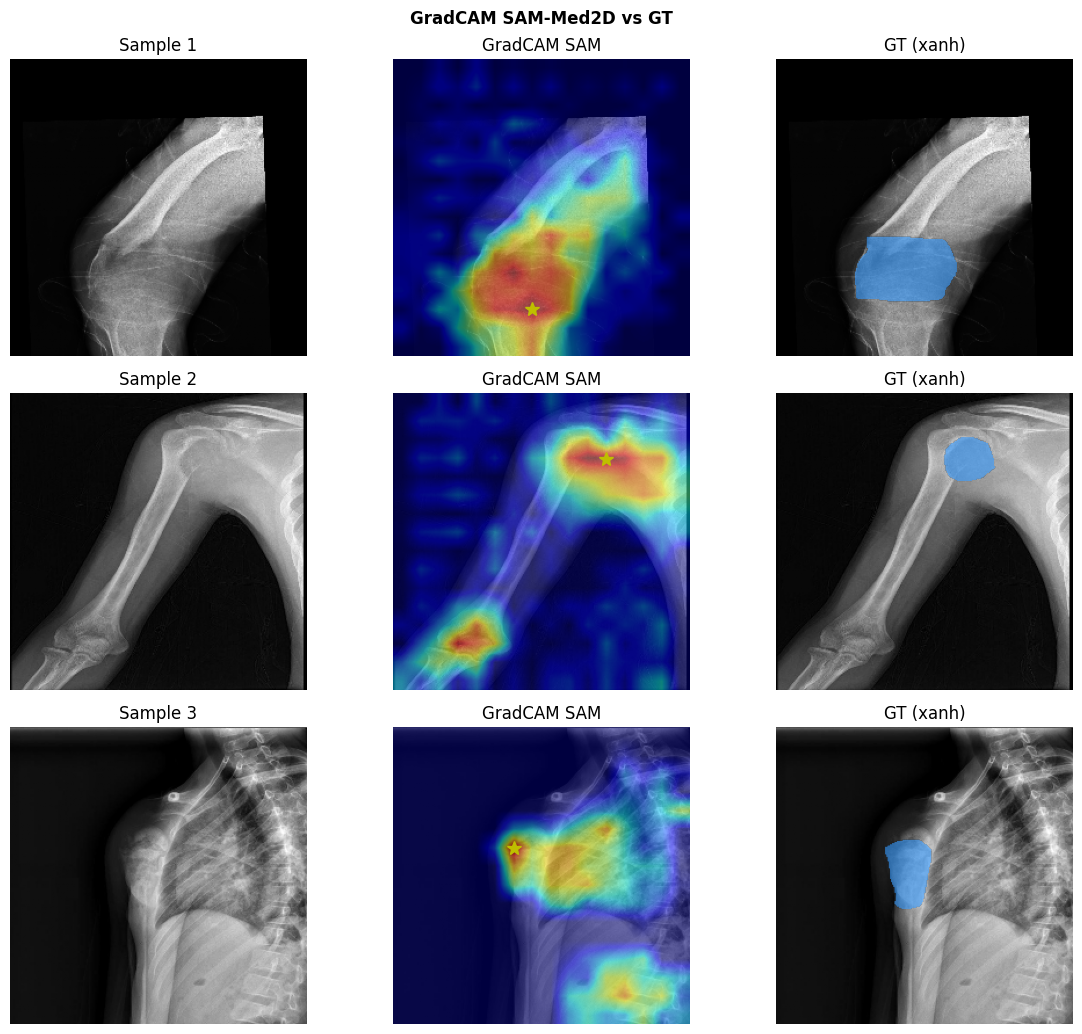

✅ sam_gradcam.png


In [14]:
# ── GradCAM trên SAM: có gợi ý được không? ───────────────────────────
import matplotlib.pyplot as plt

def compute_gradcam_sam(img_gray_uint8):
    """GradCAM từ last block ViT encoder SAM, zero prompt."""
    grads, acts = [], []
    last_block   = model.image_encoder.blocks[-1]

    def _hook(m, inp, out):
        # FIX: SAM ViT block trả về tuple (x, attn_weights) → lấy phần tử đầu
        tensor = out[0] if isinstance(out, tuple) else out
        acts.append(tensor)
        tensor.register_hook(lambda g: grads.append(g))

    h = last_block.register_forward_hook(_hook)

    img_rgb = cv2.cvtColor(img_gray_uint8, cv2.COLOR_GRAY2RGB)
    img_t   = model.preprocess(
        torch.from_numpy(img_rgb).permute(2,0,1).unsqueeze(0).float().to(DEVICE))
    zero_box = torch.tensor([[[0.,0.,1.,1.]]],device=DEVICE)
    emb      = model.image_encoder(img_t)
    se, de   = model.prompt_encoder(points=None, boxes=zero_box, masks=None)
    low, _   = model.mask_decoder(
        image_embeddings=emb, image_pe=model.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=se, dense_prompt_embeddings=de,
        multimask_output=False,
    )
    model.zero_grad(); low.sum().backward(); h.remove()

    if not grads or not acts: return None

    act = acts[0]; grd = grads[0]
    # ViT SAM output shape: [B, H, W, C] (window attention output)
    if act.dim() == 4 and act.shape[-1] > act.shape[1]:  # [B,H,W,C]
        act = act.permute(0,3,1,2); grd = grd.permute(0,3,1,2)
    elif act.dim() == 3:   # [B, seq, C] — fallback
        B,L,C = act.shape; sz = int(L**0.5)
        if sz*sz != L: return None
        act = act.reshape(B,sz,sz,C).permute(0,3,1,2)
        grd = grd.reshape(B,sz,sz,C).permute(0,3,1,2)
    # [B,C,H,W] → GradCAM
    w   = grd.mean(dim=(2,3), keepdim=True)
    cam = F.relu((w*act).sum(1, keepdim=True))
    cam = F.interpolate(cam,(S_SAM,S_SAM),mode='bilinear',align_corners=False)
    cam = cam[0,0].detach().cpu().numpy()
    mx  = cam.max(); return cam/mx if mx > 0 else None

# Lấy tối đa 10 mẫu có dark corner để test GradCAM
vis_items = []
for jfile in sorted(os.listdir(JSON_DIR)):
    if len(vis_items) >= 10: break
    if not jfile.endswith('.json'): continue
    base = os.path.splitext(jfile)[0]
    img_path = next((os.path.join(IMG_DIR,base+ext)
                     for ext in ('.png','.jpg','.jpeg')
                     if os.path.exists(os.path.join(IMG_DIR,base+ext))), None)
    if not img_path: continue
    img_bgr      = cv2.imread(img_path)
    if img_bgr is None: continue
    img_gray_orig = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    H0,W0         = img_gray_orig.shape
    img_512       = cv2.resize(img_gray_orig,(S_PGA,S_PGA))
    img_norm_512  = (img_512.astype(np.float32)/255.-0.5)/0.5
    best_ratio=-1.
    for x,y in CORNERS_512:
        r = float((img_norm_512[y:y+BOX,x:x+BOX]<DARK_NORM).mean())
        if r>best_ratio: best_ratio=r
    if best_ratio < DARK_RATIO: continue
    with open(os.path.join(JSON_DIR,jfile),'r') as f: data=_json.load(f)
    polys=[s for s in data.get('shapes',[]) if s.get('shape_type')=='polygon']
    if not polys: continue
    pts=np.array(polys[0]['points'],dtype=np.float32)
    img_gray_256=cv2.resize(img_gray_orig,(S_SAM,S_SAM))
    sx,sy=S_SAM/W0,S_SAM/H0
    pts_s=pts*np.array([sx,sy])
    gt_256=np.zeros((S_SAM,S_SAM),dtype=np.uint8)
    cv2.fillPoly(gt_256,[pts_s.astype(np.int32)],255)
    vis_items.append((img_gray_256,(gt_256>0)))

# Tính GradCAM CBL
cbl_scores = []
for img_g256, gt_bin in vis_items:
    cam = compute_gradcam_sam(img_g256)
    if cam is None: continue
    py_c,px_c = np.unravel_index(cam.argmax(), cam.shape)
    ys,xs = np.where(gt_bin)
    if len(xs) == 0: continue
    gt_d = np.sqrt((ys.max()-ys.min())**2+(xs.max()-xs.min())**2)+1e-6
    cbl  = float(np.clip(1.-np.sqrt((px_c-xs.mean())**2+(py_c-ys.mean())**2)/gt_d,0,1))
    cbl_scores.append(cbl)

print(f'\n{"="*55}')
print(f'  GRADCAM SAM-Med2D (n={len(cbl_scores)} mẫu tested)')
print(f'{"="*55}')
if cbl_scores:
    mean_cbl = np.mean(cbl_scores)
    print(f'  CBL đỉnh GradCAM (TB): {mean_cbl:.4f}')
    print(f'  (Tham chiếu PGA CBL  : 0.2975)')
    if mean_cbl >= 0.5:
        print(f'  → GradCAM SAM trỏ KHÁ ĐÚNG — có tiềm năng rescue nếu thêm IPR')
        print(f'  → Nhưng SAM KHÔNG có IPR sẵn')
    elif mean_cbl >= 0.25:
        print(f'  → GradCAM SAM tương đương PGA (cùng yếu, CBL ≈ 0.3)')
        print(f'  → Cả 2 đều khó dùng GradCAM để rescue vùng tối')
    else:
        print(f'  → GradCAM SAM KHÔNG trỏ đúng vùng tổn thương')
        print(f'  → SAM không có cơ chế tự gợi ý khi prompt xấu')
else:
    print('  Không extract được activation → SAM không có rescue nội tại')
print(f'{"="*55}')

# Visualize 3 mẫu
if cbl_scores and vis_items:
    n_show = min(3, len(vis_items))
    fig, axes = plt.subplots(n_show, 3, figsize=(12, n_show*3.5))
    if n_show == 1: axes = [axes]
    for ri, (img_g, gt_b) in enumerate(vis_items[:n_show]):
        cam = compute_gradcam_sam(img_g)
        axes[ri][0].imshow(img_g,cmap='gray'); axes[ri][0].set_title(f'Sample {ri+1}'); axes[ri][0].axis('off')
        if cam is not None:
            axes[ri][1].imshow(img_g,cmap='gray')
            axes[ri][1].imshow(cam,cmap='jet',alpha=0.5)
            py_c,px_c=np.unravel_index(cam.argmax(),cam.shape)
            axes[ri][1].plot(px_c,py_c,'y*',ms=10)
        axes[ri][1].set_title('GradCAM SAM'); axes[ri][1].axis('off')
        axes[ri][2].imshow(img_g,cmap='gray')
        ov=np.zeros((*img_g.shape,4),dtype=np.float32); ov[gt_b]=[0.2,0.6,1.0,0.6]
        axes[ri][2].imshow(ov); axes[ri][2].set_title('GT (xanh)'); axes[ri][2].axis('off')
    plt.suptitle('GradCAM SAM-Med2D vs GT',fontweight='bold'); plt.tight_layout()
    plt.savefig('sam_gradcam.png',dpi=120,bbox_inches='tight'); plt.show()
    print('✅ sam_gradcam.png')


  TỔNG KẾT — SAM-Med2D phòng hộ (N=174)
  1. Detection rate (is_suspicious):
     SAM : 174/174 = 100.0%
     PGA : 174/174 = 100.0%  [kết quả notebook GradCAM_IPR]

  2. Dice SAM khi prompt xấu: 0.0007 (TB)

  3. GradCAM rescue:
     SAM GradCAM CBL: 0.4973  |  PGA GradCAM CBL: 0.2975
     → TỐT HƠN PGA

  4. Kết luận:
     ✅ SAM phát hiện prompt xấu tốt (100.0%)
     ❌ SAM KHÔNG có rescue mechanism (GradCAM+IPR) như PGA
     → Khi prompt xấu: SAM trả kết quả sai mà không có fallback


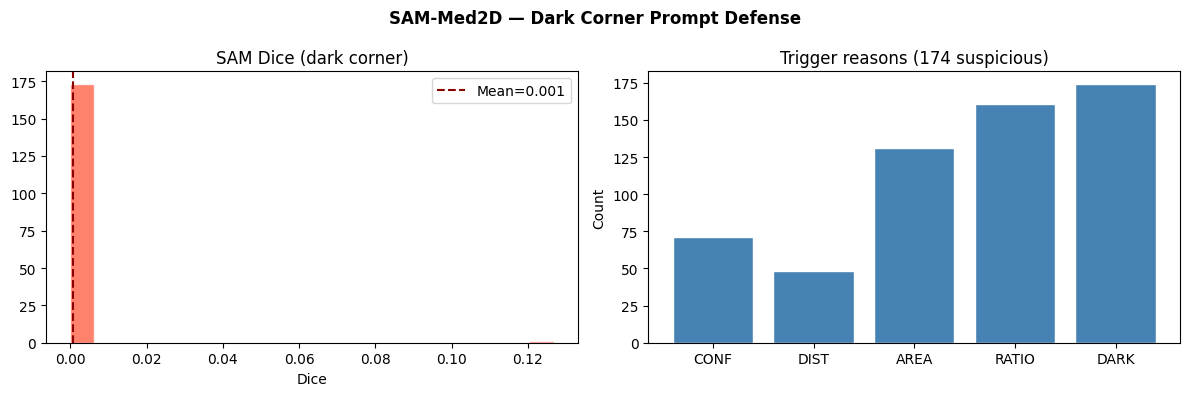

✅ sam_defense_summary.png


In [15]:
# ── Bảng tổng kết ────────────────────────────────────────────────────
import matplotlib.pyplot as plt

bar='='*60
print(f'\n{bar}')
print(f'  TỔNG KẾT — SAM-Med2D phòng hộ (N={N})')
print(f'{bar}')
print(f'  1. Detection rate (is_suspicious):')
print(f'     SAM : {n_detected}/{N} = {n_detected/N*100:.1f}%')
print(f'     PGA : 174/174 = 100.0%  [kết quả notebook GradCAM_IPR]')
print()
print(f'  2. Dice SAM khi prompt xấu: {np.mean([r["dice"] for r in records]):.4f} (TB)')
print()
print(f'  3. GradCAM rescue:')
if cbl_scores:
    mc=np.mean(cbl_scores)
    print(f'     SAM GradCAM CBL: {mc:.4f}  |  PGA GradCAM CBL: 0.2975')
    verdict = 'TỐT HƠN PGA' if mc>0.3 else ('TƯƠNG ĐƯƠNG' if mc>0.2 else 'KÉM HƠN PGA')
    print(f'     → {verdict}')
else:
    print('     SAM: không extract được GradCAM → không có rescue')
print()
print(f'  4. Kết luận:')
detect_pct=n_detected/N*100
if detect_pct>=90:
    print(f'     ✅ SAM phát hiện prompt xấu tốt ({detect_pct:.1f}%)')
else:
    print(f'     ⚠️  SAM ít nhạy hơn PGA ({detect_pct:.1f}% vs 100%)')
print(f'     ❌ SAM KHÔNG có rescue mechanism (GradCAM+IPR) như PGA')
print(f'     → Khi prompt xấu: SAM trả kết quả sai mà không có fallback')
print(f'{bar}')

# Biểu đồ
fig,axes=plt.subplots(1,2,figsize=(12,4))
fig.suptitle('SAM-Med2D — Dark Corner Prompt Defense',fontweight='bold')
all_dice=[r['dice'] for r in records]
axes[0].hist(all_dice,bins=20,color='tomato',edgecolor='white',alpha=0.8)
axes[0].axvline(np.mean(all_dice),color='darkred',ls='--',label=f'Mean={np.mean(all_dice):.3f}')
axes[0].set_title('SAM Dice (dark corner)'); axes[0].set_xlabel('Dice'); axes[0].legend()
if susp_recs:
    ks=['CONF','DIST','AREA','RATIO','DARK']
    cnts=[sum(r['reasons'][k] for r in susp_recs) for k in ks]
    axes[1].bar(ks,cnts,color='steelblue',edgecolor='white')
    axes[1].set_title(f'Trigger reasons ({n_detected} suspicious)')
    axes[1].set_ylabel('Count')
plt.tight_layout(); plt.savefig('sam_defense_summary.png',dpi=120,bbox_inches='tight')
plt.show(); print('✅ sam_defense_summary.png')